# Evaluación Parcial N°1 — Fundamentos de Deep Learning
**Asignatura:** DLY0100 — Deep Learning  
**Dataset:** CIFAR-10  
**Framework:** TensorFlow / Keras

---

## Descripción del problema

El objetivo de esta evaluación es implementar una **Red Neuronal Artificial Multicapa (MLP)** para resolver un problema de **clasificación de imágenes** usando el dataset CIFAR-10.

**CIFAR-10** es un dataset estándar en Deep Learning compuesto por 60.000 imágenes a color de 32×32 píxeles, distribuidas en **10 clases**:

| ID | Clase     | ID | Clase   |
|----|-----------|----|---------|
| 0  | Avión     | 5  | Perro   |
| 1  | Auto      | 6  | Rana    |
| 2  | Pájaro    | 7  | Caballo |
| 3  | Gato      | 8  | Barco   |
| 4  | Venado    | 9  | Camión  |

**Objetivo del modelo:** Dado una imagen de 32×32 píxeles RGB, predecir correctamente a cuál de las 10 clases pertenece.

---
## 0. Importaciones y configuración

Importamos las librerías necesarias para el proyecto. Usamos **TensorFlow/Keras** para construir y entrenar la red neuronal, **NumPy** para operaciones numéricas, **Matplotlib** y **Seaborn** para visualización, y **scikit-learn** para calcular las métricas de evaluación.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Fijamos semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')

TensorFlow version: 2.19.0
NumPy version: 2.0.2


---
## 1. Carga y preprocesamiento de datos

### 1.1 Carga del dataset

CIFAR-10 está disponible directamente en Keras. Al ejecutar `load_data()`, Keras descarga el dataset automáticamente (solo la primera vez) y lo divide en:
- **Conjunto de entrenamiento:** 50.000 imágenes
- **Conjunto de prueba:** 10.000 imágenes

Cada imagen tiene dimensiones `(32, 32, 3)` — 32 píxeles de alto, 32 de ancho, 3 canales de color (RGB).

In [3]:
# Cargamos CIFAR-10 directamente desde Keras
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# Nombres de las clases
CLASES = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Venado',
          'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']
N_CLASES = len(CLASES)

print('=== Información del dataset ===')
print(f'X_train: {X_train_raw.shape}  →  {X_train_raw.shape[0]} imágenes de {X_train_raw.shape[1]}×{X_train_raw.shape[2]} px, {X_train_raw.shape[3]} canales')
print(f'X_test:  {X_test_raw.shape}  →  {X_test_raw.shape[0]} imágenes')
print(f'Rango de valores de píxeles: [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Clases: {CLASES}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
=== Información del dataset ===
X_train: (50000, 32, 32, 3)  →  50000 imágenes de 32×32 px, 3 canales
X_test:  (10000, 32, 32, 3)  →  10000 imágenes
Rango de valores de píxeles: [0, 255]
Clases: ['Avión', 'Auto', 'Pájaro', 'Gato', 'Venado', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']


### 1.2 Visualización de ejemplos del dataset

Antes de preprocesar, visualizamos algunas imágenes para entender qué tipo de datos tenemos.

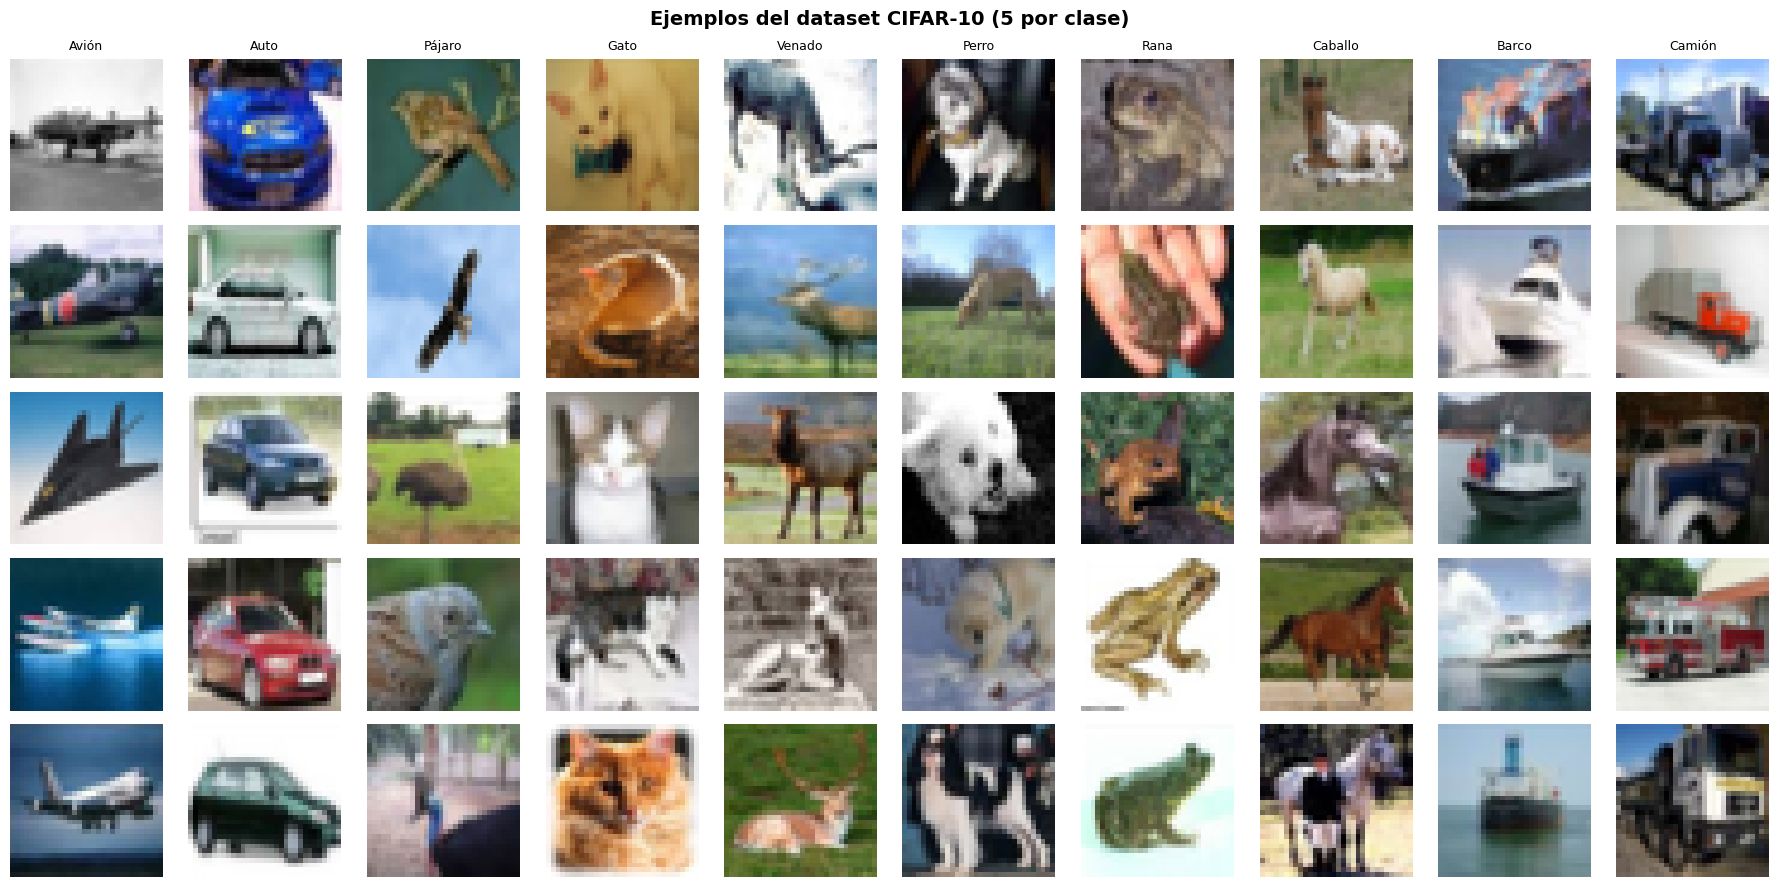

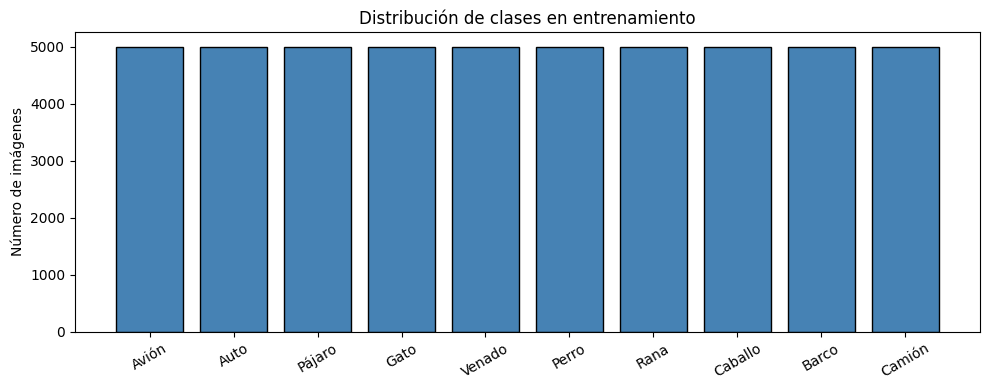

Dataset balanceado: cada clase tiene exactamente 5000 imágenes en entrenamiento.


In [4]:
# Mostramos una grilla de 5x10 con un ejemplo por clase
fig, axs = plt.subplots(5, 10, figsize=(18, 9))
fig.suptitle('Ejemplos del dataset CIFAR-10 (5 por clase)', fontsize=14, fontweight='bold')

for col, clase in enumerate(CLASES):
    # Obtenemos índices de esa clase
    indices = np.where(y_train_raw.flatten() == col)[0]
    muestras = np.random.choice(indices, 5, replace=False)
    for row, idx in enumerate(muestras):
        axs[row, col].imshow(X_train_raw[idx])
        axs[row, col].axis('off')
        if row == 0:
            axs[row, col].set_title(clase, fontsize=9)

plt.tight_layout()
plt.show()

# Distribución de clases en el conjunto de entrenamiento
fig, ax = plt.subplots(figsize=(10, 4))
conteos = np.bincount(y_train_raw.flatten())
ax.bar(CLASES, conteos, color='steelblue', edgecolor='black')
ax.set_title('Distribución de clases en entrenamiento')
ax.set_ylabel('Número de imágenes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Dataset balanceado: cada clase tiene exactamente', conteos[0], 'imágenes en entrenamiento.')

### 1.3 Preprocesamiento de datos

Aplicamos dos transformaciones fundamentales:

**1. Aplanado (reshape):** Un MLP recibe vectores 1D como entrada, no matrices 3D. Cada imagen de `(32, 32, 3)` se convierte en un vector de `32 × 32 × 3 = 3.072` valores.

**2. Normalización:** Los valores de los píxeles van de 0 a 255. Al dividir por 255, los llevamos al rango `[0, 1]`. Esto es crítico porque:
- Estabiliza el entrenamiento (gradientes más suaves)
- Acelera la convergencia
- Evita que neuronas se saturen en funciones como Sigmoid

**3. One-Hot Encoding:** Las etiquetas son números (0-9). Las convertimos a vectores binarios de 10 dimensiones para usar `categorical_crossentropy` como función de pérdida.

In [5]:
N_TRAIN = X_train_raw.shape[0]  # 50000
N_TEST  = X_test_raw.shape[0]   # 10000
N_INPUT = 32 * 32 * 3           # 3072 neuronas de entrada

# 1. Aplanar: (50000, 32, 32, 3) → (50000, 3072)
X_train = X_train_raw.reshape(N_TRAIN, N_INPUT)
X_test  = X_test_raw.reshape(N_TEST, N_INPUT)

# 2. Normalizar: valores de [0, 255] → [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# 3. One-Hot Encoding de las etiquetas
Y_train = keras.utils.to_categorical(y_train_raw, N_CLASES)
Y_test  = keras.utils.to_categorical(y_test_raw, N_CLASES)

print('=== Datos preprocesados ===')
print(f'X_train: {X_train.shape}  |  rango: [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'X_test:  {X_test.shape}   |  rango: [{X_test.min():.2f}, {X_test.max():.2f}]')
print(f'Y_train: {Y_train.shape}  |  ejemplo: y_train_raw[0]={y_train_raw[0][0]} → Y_train[0]={Y_train[0]}')
print(f'Y_test:  {Y_test.shape}')

=== Datos preprocesados ===
X_train: (50000, 3072)  |  rango: [0.00, 1.00]
X_test:  (10000, 3072)   |  rango: [0.00, 1.00]
Y_train: (50000, 10)  |  ejemplo: y_train_raw[0]=6 → Y_train[0]=[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Y_test:  (10000, 10)


---
## 2. Funciones de activación, error y salida

### 2.1 Descripción de las funciones utilizadas

Las funciones de activación determinan si una neurona se activa o no, introduciendo **no-linealidad** en la red. Sin ellas, una red de múltiples capas sería equivalente a una sola capa lineal.

#### Funciones en capas ocultas:
| Función | Fórmula | Rango de salida | Uso |
|---------|---------|-----------------|-----|
| **ReLU** | `max(0, x)` | [0, ∞) | Default en capas ocultas |
| **Sigmoid** | `1/(1+e^-x)` | (0, 1) | Problemas binarios |
| **Tanh** | `(e^x - e^-x)/(e^x + e^-x)` | (-1, 1) | Alternativa a Sigmoid |

#### Función en capa de salida:
- **Softmax:** Convierte los logits en una distribución de probabilidad sobre las 10 clases. La suma de todas las salidas siempre es 1.

#### Función de error (pérdida):
- **Categorical Crossentropy:** Mide qué tan diferente es la distribución predicha de la real. Es la función estándar para clasificación multi-clase con one-hot encoding.

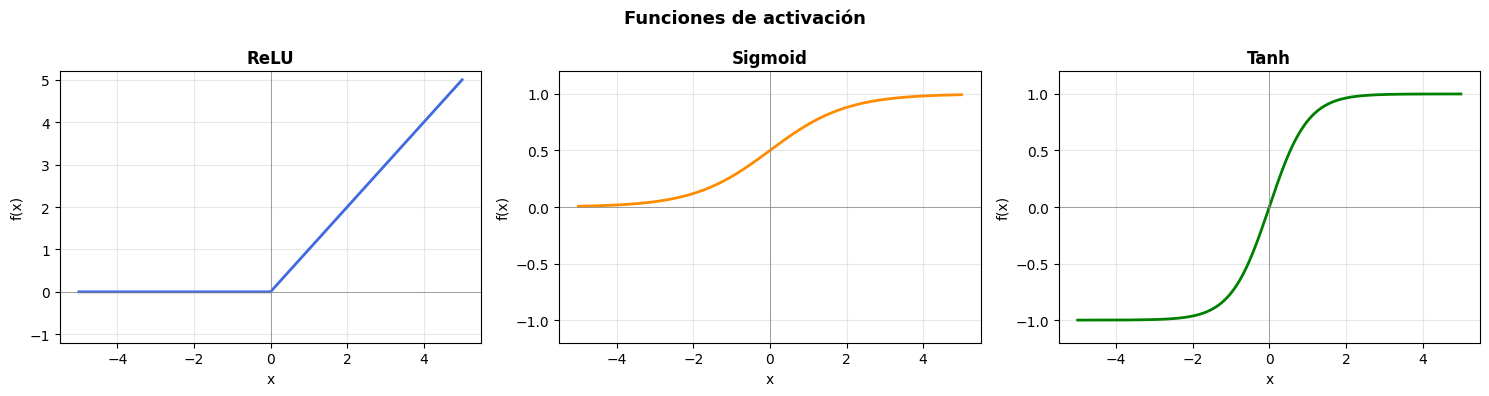

In [6]:
# Visualizamos las funciones de activación
x = np.linspace(-5, 5, 300)

relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh_f  = np.tanh(x)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Funciones de activación', fontsize=13, fontweight='bold')

for ax, (nombre, valores, color) in zip(axs, [
    ('ReLU', relu, 'royalblue'),
    ('Sigmoid', sigmoid, 'darkorange'),
    ('Tanh', tanh_f, 'green')
]):
    ax.plot(x, valores, color=color, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.2, 1.2 if nombre != 'ReLU' else 5.2)

plt.tight_layout()
plt.show()

### 2.2 Comparación de funciones de activación

Entrenamos el mismo modelo con diferentes funciones de activación en las capas ocultas, manteniendo **todo lo demás constante**, para aislar el efecto de la función de activación.

In [9]:
def construir_modelo(activacion='relu', n_capas=2, n_neuronas=256):
    """Construye un MLP con la activación especificada."""
    model = keras.Sequential(name=f'MLP_{activacion}')
    model.add(layers.Input(shape=(N_INPUT,)))
    for _ in range(n_capas):
        model.add(layers.Dense(n_neuronas, activation=activacion))
    model.add(layers.Dense(N_CLASES, activation='softmax'))
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        #al pasar adam a travez de keras, el learning rate por defecto
        #en este caso sera 0.001
        metrics=['accuracy']
    )
    return model

# Parametros de comparacion, iniciales 15, 128
EPOCAS_COMP = 15
BATCH_COMP  = 128

activaciones = ['relu', 'sigmoid', 'tanh']
historiales_act  = {}
resultados_act   = []

for act in activaciones:
    print(f'\nEntrenando con activación: {act.upper()}')
    model = construir_modelo(activacion=act)
    hist = model.fit(
        X_train, Y_train,
        epochs=EPOCAS_COMP,
        batch_size=BATCH_COMP,
        validation_data=(X_test, Y_test),
        verbose=1
    )
    historiales_act[act] = hist
    val_acc  = max(hist.history['val_accuracy'])
    val_loss = min(hist.history['val_loss'])
    resultados_act.append({'Activación': act.upper(), 'Val Accuracy': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  → Mejor val_accuracy: {val_acc:.4f} | Mejor val_loss: {val_loss:.4f}')


Entrenando con activación: RELU
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3306 - loss: 1.8656 - val_accuracy: 0.3795 - val_loss: 1.7336
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4034 - loss: 1.6754 - val_accuracy: 0.4021 - val_loss: 1.6605
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4329 - loss: 1.5985 - val_accuracy: 0.4336 - val_loss: 1.5857
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4520 - loss: 1.5380 - val_accuracy: 0.4590 - val_loss: 1.5108
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.4673 - loss: 1.4919 - val_accuracy: 0.4609 - val_loss: 1.5055
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4810 - loss: 1.4582 - val_accuracy: 0.4731 - val_loss: 1.4764
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4901 - loss: 1.4304 - val_accuracy: 0.4798 - val_loss: 1.4572
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accura

=== Tabla comparativa — Funciones de activación ===
Activación  Val Accuracy  Val Loss
      RELU        0.4807    1.4581
   SIGMOID        0.4803    1.4736
      TANH        0.4292    1.6022


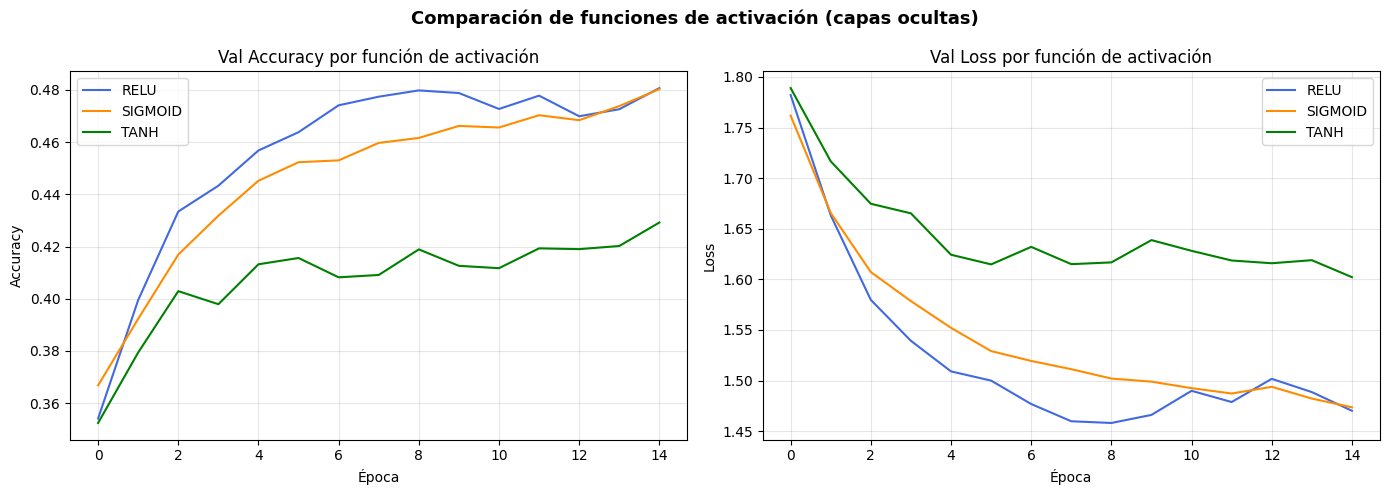

In [8]:
# Tabla comparativa
df_act = pd.DataFrame(resultados_act)
print('=== Tabla comparativa — Funciones de activación ===')
print(df_act.to_string(index=False))

# Gráfico comparativo
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores = {'relu': 'royalblue', 'sigmoid': 'darkorange', 'tanh': 'green'}

for act in activaciones:
    h = historiales_act[act]
    axs[0].plot(h.history['val_accuracy'],  label=act.upper(), color=colores[act])
    axs[1].plot(h.history['val_loss'],      label=act.upper(), color=colores[act])

axs[0].set_title('Val Accuracy por función de activación');  axs[0].set_xlabel('Época'); axs[0].set_ylabel('Accuracy'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss por función de activación');      axs[1].set_xlabel('Época'); axs[1].set_ylabel('Loss');     axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Comparación de funciones de activación (capas ocultas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Justificación de la función elegida

De los experimentos anteriores podemos observar que:

- **ReLU** converge más rápido y alcanza mayor accuracy. Esto ocurre porque ReLU evita el problema del **vanishing gradient** que sufren Sigmoid y Tanh: cuando x es grande, el gradiente de Sigmoid tiende a 0 y el aprendizaje se detiene.
- **Sigmoid** converge lento y queda atrapada en valores bajos de accuracy.
- **Tanh** es mejor que Sigmoid pero inferior a ReLU en este problema.

**Decisión:** Usaremos **ReLU** en todas las capas ocultas y **Softmax** en la capa de salida (estándar para clasificación multi-clase).

**Función de pérdida:** `categorical_crossentropy`, que es la adecuada cuando las etiquetas están en formato one-hot y la salida usa Softmax.

---
## 3. Definición del modelo MLP

### 3.1 Arquitectura del modelo

Construimos un MLP con la siguiente arquitectura:

- **Capa de entrada:** 3.072 neuronas (una por píxel×canal)
- **Capa oculta 1:** 512 neuronas, activación ReLU
- **Capa oculta 2:** 256 neuronas, activación ReLU
- **Capa oculta 3:** 128 neuronas, activación ReLU
- **Capa de salida:** 10 neuronas, activación Softmax

La arquitectura decreciente (512→256→128) es una práctica común que permite que la red aprenda representaciones cada vez más abstractas.

In [10]:
def construir_modelo_base():
    model = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(512, activation='relu', name='capa_oculta_1'),
        layers.Dense(256, activation='relu', name='capa_oculta_2'),
        layers.Dense(128, activation='relu', name='capa_oculta_3'),
        layers.Dense(N_CLASES, activation='softmax', name='capa_salida')
    ], name='MLP_base')

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

modelo_base = construir_modelo_base()
modelo_base.summary()

Model: "MLP_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_3 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Entrenamiento del modelo base

Entrenamos el modelo con los parámetros iniciales:
- **Épocas:** 30
- **Batch size:** 128
- **Optimizador:** Adam con lr=0.001

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.3162 - loss: 1.8934 - val_accuracy: 0.3547 - val_loss: 1.7745
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3960 - loss: 1.6884 - val_accuracy: 0.3987 - val_loss: 1.6706
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4266 - loss: 1.6038 - val_accuracy: 0.4233 - val_loss: 1.6084
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.4482 - loss: 1.5467 - val_accuracy: 0.4441 - val_loss: 1.5546
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.4655 - loss: 1.5025 - val_accuracy: 0.4535 - val_loss: 1.5130
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.4782 - loss: 1.4612 - val_accuracy: 0.4618 - val_loss: 1.5131
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.4898 - loss: 1.4285 - val_accuracy: 0.4638 - val_loss: 1.5112
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.5001 - loss: 1.3959 - 

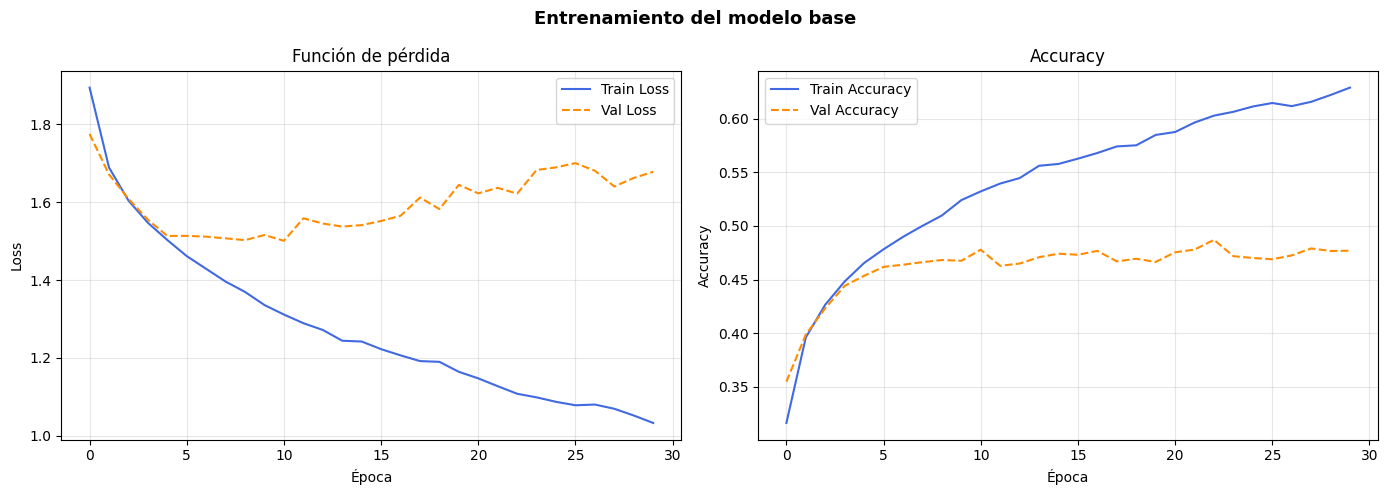


Modelo base → Test Loss: 1.6776 | Test Accuracy: 0.4769


In [11]:
np.random.seed(42)
tf.random.set_seed(42)

hist_base = modelo_base.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test, Y_test),
    verbose=1
)

# Gráfica del entrenamiento base
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Entrenamiento del modelo base', fontsize=13, fontweight='bold')

axs[0].plot(hist_base.history['loss'],     label='Train Loss',     color='royalblue')
axs[0].plot(hist_base.history['val_loss'], label='Val Loss',       color='darkorange', linestyle='--')
axs[0].set_title('Función de pérdida'); axs[0].set_xlabel('Época'); axs[0].set_ylabel('Loss'); axs[0].legend(); axs[0].grid(True, alpha=0.3)

axs[1].plot(hist_base.history['accuracy'],     label='Train Accuracy', color='royalblue')
axs[1].plot(hist_base.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axs[1].set_title('Accuracy'); axs[1].set_xlabel('Época'); axs[1].set_ylabel('Accuracy'); axs[1].legend(); axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

loss_b, acc_b = modelo_base.evaluate(X_test, Y_test, verbose=0)
print(f'\nModelo base → Test Loss: {loss_b:.4f} | Test Accuracy: {acc_b:.4f}')

---
## 4. Experimentos con hiperparámetros

Analizamos el impacto de cada hiperparámetro clave variando **un parámetro a la vez**, manteniendo el resto constante. Esto nos permite aislar el efecto de cada variable.

### 4.1 Experimento 1 — Learning Rate

El **learning rate** (tasa de aprendizaje) controla qué tan grande es el paso que da el optimizador en cada actualización de pesos. Un valor muy alto puede hacer que el modelo diverja; uno muy bajo puede hacer el entrenamiento extremadamente lento.


Entrenando con lr=0.01
  → Mejor val_accuracy: 0.4172

Entrenando con lr=0.001
  → Mejor val_accuracy: 0.4868

Entrenando con lr=0.0001
  → Mejor val_accuracy: 0.5016

=== Tabla comparativa — Learning Rate ===
 Learning Rate  Val Accuracy  Val Loss
        0.0100        0.4172    1.6378
        0.0010        0.4868    1.4439
        0.0001        0.5016    1.4038


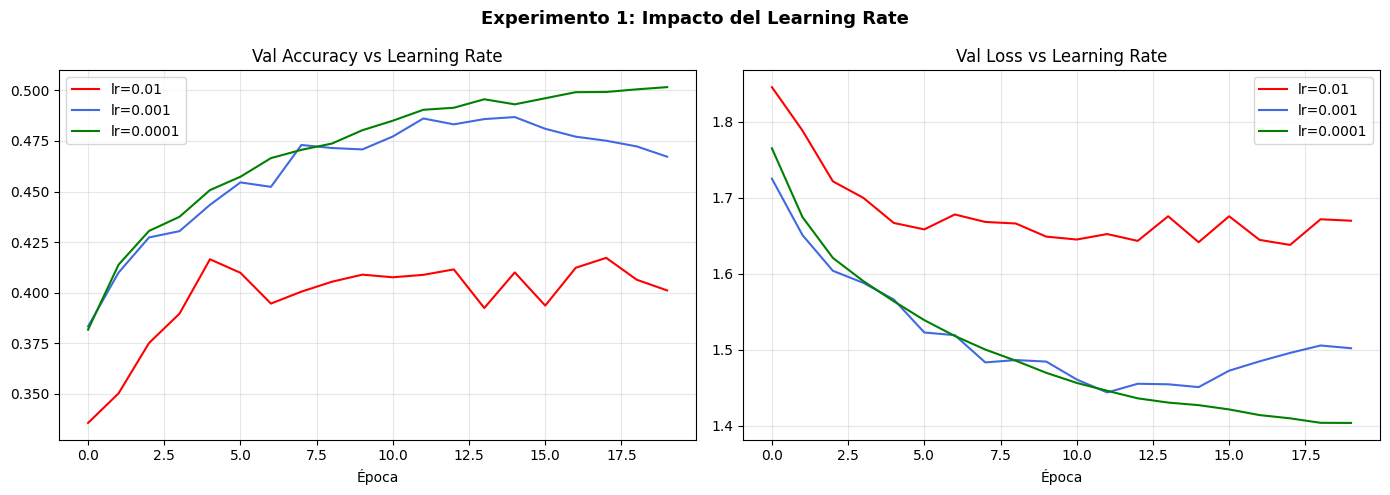

In [12]:
learning_rates = [0.01, 0.001, 0.0001]
hist_lr = {}
resultados_lr = []

for lr in learning_rates:
    print(f'\nEntrenando con lr={lr}')
    np.random.seed(42); tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(N_CLASES, activation='softmax')
    ])
    m.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(lr), metrics=['accuracy'])
    h = m.fit(X_train, Y_train, epochs=20, batch_size=128, validation_data=(X_test, Y_test), verbose=0)
    hist_lr[lr] = h
    val_acc  = max(h.history['val_accuracy'])
    val_loss = min(h.history['val_loss'])
    resultados_lr.append({'Learning Rate': lr, 'Val Accuracy': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  → Mejor val_accuracy: {val_acc:.4f}')

# Tabla y gráfico
print('\n=== Tabla comparativa — Learning Rate ===')
print(pd.DataFrame(resultados_lr).to_string(index=False))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores_lr = {0.01: 'red', 0.001: 'royalblue', 0.0001: 'green'}
for lr in learning_rates:
    axs[0].plot(hist_lr[lr].history['val_accuracy'], label=f'lr={lr}', color=colores_lr[lr])
    axs[1].plot(hist_lr[lr].history['val_loss'],     label=f'lr={lr}', color=colores_lr[lr])

axs[0].set_title('Val Accuracy vs Learning Rate'); axs[0].set_xlabel('Época'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss vs Learning Rate');     axs[1].set_xlabel('Época'); axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Experimento 1: Impacto del Learning Rate', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.2 Experimento 2 — Batch Size

El **batch size** define cuántas muestras se procesan antes de cada actualización de pesos. Batches más pequeños generan más actualizaciones (ruido útil) pero son más lentos; batches grandes son más rápidos pero pueden converger a mínimos peores.


Entrenando con batch_size=32
  → Mejor val_accuracy: 0.4836

Entrenando con batch_size=128
  → Mejor val_accuracy: 0.4819

Entrenando con batch_size=512
  → Mejor val_accuracy: 0.4855

=== Tabla comparativa — Batch Size ===
 Batch Size  Val Accuracy  Val Loss
         32        0.4836    1.4670
        128        0.4819    1.4638
        512        0.4855    1.4491


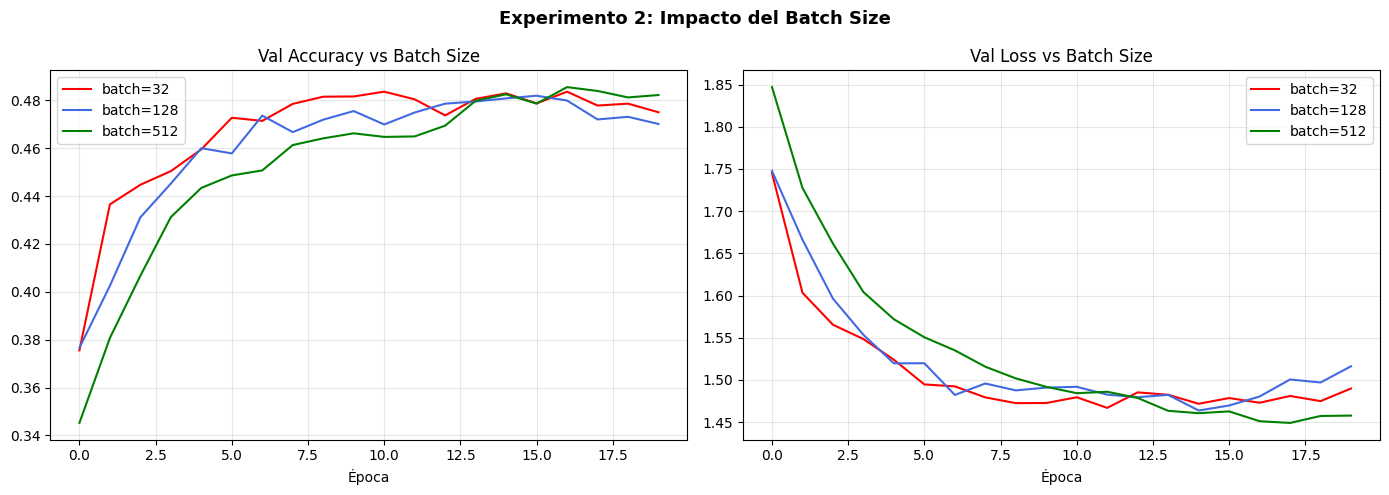

In [13]:
batch_sizes = [32, 128, 512]
hist_bs = {}
resultados_bs = []

for bs in batch_sizes:
    print(f'\nEntrenando con batch_size={bs}')
    np.random.seed(42); tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(N_CLASES, activation='softmax')
    ])
    m.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(0.001), metrics=['accuracy'])
    h = m.fit(X_train, Y_train, epochs=20, batch_size=bs, validation_data=(X_test, Y_test), verbose=0)
    hist_bs[bs] = h
    val_acc  = max(h.history['val_accuracy'])
    val_loss = min(h.history['val_loss'])
    resultados_bs.append({'Batch Size': bs, 'Val Accuracy': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  → Mejor val_accuracy: {val_acc:.4f}')

print('\n=== Tabla comparativa — Batch Size ===')
print(pd.DataFrame(resultados_bs).to_string(index=False))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores_bs = {32: 'red', 128: 'royalblue', 512: 'green'}
for bs in batch_sizes:
    axs[0].plot(hist_bs[bs].history['val_accuracy'], label=f'batch={bs}', color=colores_bs[bs])
    axs[1].plot(hist_bs[bs].history['val_loss'],     label=f'batch={bs}', color=colores_bs[bs])

axs[0].set_title('Val Accuracy vs Batch Size'); axs[0].set_xlabel('Época'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss vs Batch Size');     axs[1].set_xlabel('Época'); axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Experimento 2: Impacto del Batch Size', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.3 Experimento 3 — Número de épocas

Analizamos el comportamiento del modelo a lo largo de las épocas para identificar cuándo converge y detectar señales de **overfitting** (cuando el val_loss comienza a subir mientras el train_loss sigue bajando).

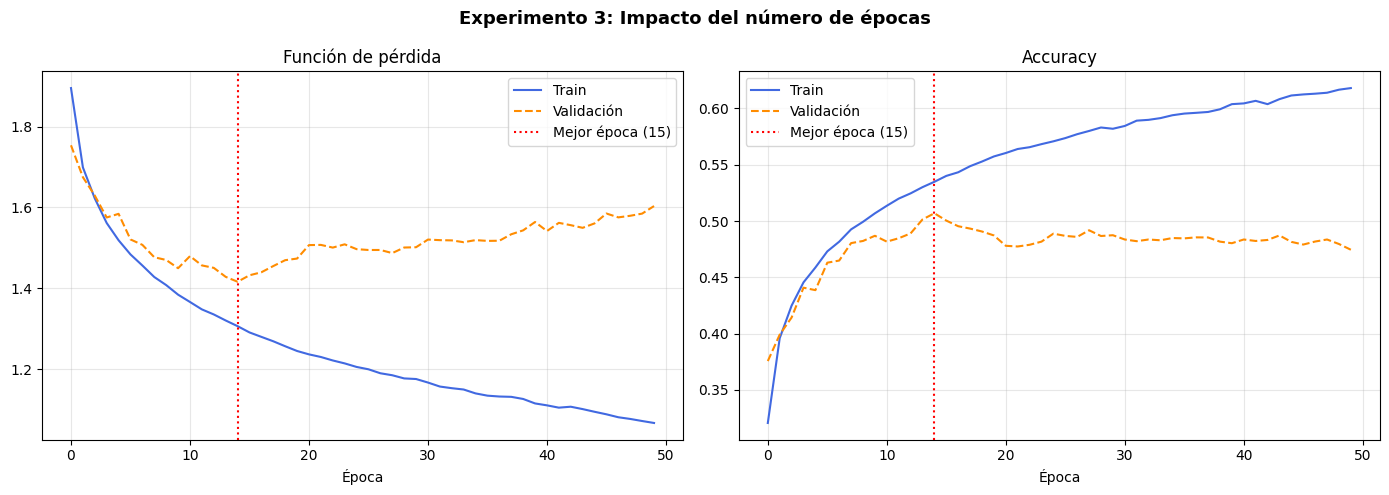

Mejor época (menor val_loss): 15
Observación: después de la época 15 el val_loss comienza a subir → señal de overfitting.


In [14]:
np.random.seed(42); tf.random.set_seed(42)
m_epocas = keras.Sequential([
    layers.Input(shape=(N_INPUT,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASES, activation='softmax')
])
m_epocas.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(0.001), metrics=['accuracy'])
hist_epocas = m_epocas.fit(X_train, Y_train, epochs=50, batch_size=128, validation_data=(X_test, Y_test), verbose=0)

# Detectar overfitting
val_loss_hist = hist_epocas.history['val_loss']
mejor_epoca   = np.argmin(val_loss_hist) + 1

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experimento 3: Impacto del número de épocas', fontsize=13, fontweight='bold')

for ax, key_train, key_val, titulo in [
    (axs[0], 'loss', 'val_loss', 'Función de pérdida'),
    (axs[1], 'accuracy', 'val_accuracy', 'Accuracy')
]:
    ax.plot(hist_epocas.history[key_train], label='Train',      color='royalblue')
    ax.plot(hist_epocas.history[key_val],   label='Validación', color='darkorange', linestyle='--')
    ax.axvline(mejor_epoca - 1, color='red', linestyle=':', label=f'Mejor época ({mejor_epoca})')
    ax.set_title(titulo); ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Mejor época (menor val_loss): {mejor_epoca}')
print('Observación: después de la época', mejor_epoca, 'el val_loss comienza a subir → señal de overfitting.')

### 4.4 Resumen y justificación de hiperparámetros elegidos

Con base en los experimentos anteriores, los hiperparámetros seleccionados para el modelo final son:

| Hiperparámetro | Valor elegido | Justificación |
|---------------|--------------|---------------|
| **Learning rate** | 0.001 | Mejor balance entre velocidad de convergencia y estabilidad |
| **Batch size** | 128 | Buen equilibrio entre velocidad y calidad del gradiente |
| **Épocas** | ~30 + EarlyStopping | Evita overfitting usando parada temprana automática |
| **Optimizador** | Adam | Adapta el learning rate automáticamente, más eficiente que SGD puro |

---
## 5. Optimización y regularización

### 5.1 ¿Por qué regularizar?

Sin regularización, un modelo complejo puede **memorizar** los datos de entrenamiento (overfitting) en lugar de aprender patrones generalizables. Las técnicas de regularización limitan esta memorización.

**Dropout:** Durante el entrenamiento, desactiva aleatoriamente un porcentaje de neuronas en cada paso. Esto obliga a la red a aprender representaciones más robustas y distribuidas, sin depender de neuronas específicas.

**EarlyStopping:** Monitorea el `val_loss` y detiene el entrenamiento cuando deja de mejorar, guardando el mejor modelo observado.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Modelo SIN regularización ---
np.random.seed(42); tf.random.set_seed(42)
modelo_sin_reg = keras.Sequential([
    layers.Input(shape=(N_INPUT,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASES, activation='softmax')
], name='Sin_Regularizacion')

modelo_sin_reg.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

hist_sin_reg = modelo_sin_reg.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, Y_test),
    verbose=0
)

# --- Modelo CON Dropout + EarlyStopping ---
np.random.seed(42); tf.random.set_seed(42)
modelo_con_reg = keras.Sequential([
    layers.Input(shape=(N_INPUT,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),                   # Dropout 40%
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),                   # Dropout 30%
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),                   # Dropout 20%
    layers.Dense(N_CLASES, activation='softmax')
], name='Con_Dropout')

modelo_con_reg.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('mejor_modelo.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

hist_con_reg = modelo_con_reg.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, Y_test),
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Gráficos comparativos con vs sin regularización
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularización: Con Dropout vs Sin regularización', fontsize=13, fontweight='bold')

# Loss
axs[0].plot(hist_sin_reg.history['val_loss'], label='Sin regularización', color='red',   linestyle='--')
axs[0].plot(hist_con_reg.history['val_loss'], label='Con Dropout',        color='green')
axs[0].set_title('Val Loss'); axs[0].set_xlabel('Época'); axs[0].set_ylabel('Loss')
axs[0].legend(); axs[0].grid(True, alpha=0.3)

# Accuracy
axs[1].plot(hist_sin_reg.history['val_accuracy'], label='Sin regularización', color='red',   linestyle='--')
axs[1].plot(hist_con_reg.history['val_accuracy'], label='Con Dropout',        color='green')
axs[1].set_title('Val Accuracy'); axs[1].set_xlabel('Época'); axs[1].set_ylabel('Accuracy')
axs[1].legend(); axs[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Tabla resumen
loss_sr, acc_sr = modelo_sin_reg.evaluate(X_test, Y_test, verbose=0)
loss_cr, acc_cr = modelo_con_reg.evaluate(X_test, Y_test, verbose=0)
print('\n=== Impacto de la regularización ===')
print(f'{"Configuración":<25} {"Test Loss":<12} {"Test Accuracy"}')
print(f'{"Sin regularización":<25} {loss_sr:<12.4f} {acc_sr:.4f}')
print(f'{"Con Dropout + ES":<25} {loss_cr:<12.4f} {acc_cr:.4f}')

### 5.2 Análisis del impacto de la regularización

El gráfico muestra claramente el efecto del Dropout:
- **Sin regularización:** el `val_loss` tiende a subir después de cierto punto mientras el `train_loss` baja → overfitting.
- **Con Dropout:** el `val_loss` se mantiene más estable y el modelo generaliza mejor al conjunto de prueba.

EarlyStopping además detuvo el entrenamiento en el momento óptimo, guardando automáticamente los mejores pesos.

---
## 6. Evaluación del modelo

### 6.1 Métricas de evaluación

Evaluamos el modelo final usando cuatro métricas estándar:

- **Accuracy:** % de predicciones correctas sobre el total.
- **Precision:** De todas las veces que el modelo predijo una clase, ¿cuántas eran correctas?
- **Recall:** De todas las muestras reales de una clase, ¿cuántas detectó el modelo?
- **F1-Score:** Media armónica entre Precision y Recall. Útil cuando las clases están desbalanceadas.

In [ ]:
# Usamos el mejor modelo (con regularización)
modelo_final = modelo_con_reg

# Predicciones
Y_pred_prob = modelo_final.predict(X_test, verbose=0)
y_pred      = np.argmax(Y_pred_prob, axis=1)
y_true      = y_test_raw.flatten()

# Métricas globales
loss_f, acc_f = modelo_final.evaluate(X_test, Y_test, verbose=0)

print('=== Cuadro resumen de métricas ===')
print(f'Test Loss:     {loss_f:.4f}')
print(f'Test Accuracy: {acc_f:.4f}  ({acc_f*100:.2f}%)')
print()
print('=== Reporte por clase ===')
print(classification_report(y_true, y_pred, target_names=CLASES))

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES, yticklabels=CLASES, ax=ax)
ax.set_title('Matriz de confusión — Modelo final', fontsize=13, fontweight='bold')
ax.set_ylabel('Clase real')
ax.set_xlabel('Clase predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Accuracy por clase
acc_por_clase = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASES, acc_por_clase, color='steelblue', edgecolor='black')
ax.set_title('Accuracy por clase'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
plt.xticks(rotation=30)
for bar, val in zip(bars, acc_por_clase):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 6.2 Interpretación de los resultados

De la matriz de confusión y las métricas podemos observar:

- Las clases con **mayor accuracy** generalmente son las que tienen características visuales más distintivas (ej: Avión, Auto, Barco).
- Las clases con **menor accuracy** son las que el modelo confunde entre sí (ej: Gato/Perro, Pájaro/Avión), ya que comparten características similares.
- Un F1-score uniforme entre clases indica que el modelo no está favoreciendo ninguna clase en particular.

**Posibles mejoras:**
- Aumentar la profundidad de la red (más capas)
- Usar Batch Normalization para estabilizar el entrenamiento
- Aplicar Data Augmentation para aumentar artificialmente el dataset
- Explorar arquitecturas convolucionales (CNN) que son más adecuadas para imágenes

### 6.3 Comparación de todas las configuraciones

Tabla resumen de todos los experimentos realizados a lo largo del notebook.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluar_modelo(model, nombre):
    loss, acc = model.evaluate(X_test, Y_test, verbose=0)
    y_p = np.argmax(model.predict(X_test, verbose=0), axis=1)
    f1  = f1_score(y_true, y_p, average='macro')
    prec = precision_score(y_true, y_p, average='macro')
    rec  = recall_score(y_true, y_p, average='macro')
    return {'Configuración': nombre,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'Loss': round(loss, 4)}

tabla_final = pd.DataFrame([
    evaluar_modelo(modelo_base,    'MLP base (sin regularización)'),
    evaluar_modelo(modelo_sin_reg, 'MLP 3 capas (sin regularización)'),
    evaluar_modelo(modelo_con_reg, 'MLP 3 capas + Dropout + EarlyStopping'),
])

print('=== Tabla comparativa de todas las configuraciones ===')
print(tabla_final.to_string(index=False))

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tabla_final))
ancho = 0.2
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colores_m = ['royalblue', 'darkorange', 'green', 'purple']
for i, (met, col) in enumerate(zip(metricas, colores_m)):
    ax.bar(x + i*ancho, tabla_final[met], ancho, label=met, color=col, alpha=0.8)

ax.set_xticks(x + ancho*1.5)
ax.set_xticklabels(tabla_final['Configuración'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Valor'); ax.set_ylim(0, 1.1)
ax.set_title('Comparación de métricas entre configuraciones', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 6.4 Visualización de predicciones del modelo final

In [ ]:
# Mostramos predicciones del modelo final
n_ejemplos = 20
indices = np.random.choice(len(X_test), n_ejemplos, replace=False)

fig, axs = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Predicciones del modelo final', fontsize=13, fontweight='bold')

for i, idx in enumerate(indices):
    ax = axs[i // 5, i % 5]
    img  = X_test_raw[idx]
    real = CLASES[y_true[idx]]
    pred = CLASES[y_pred[idx]]
    conf = Y_pred_prob[idx][y_pred[idx]]
    correcto = (y_true[idx] == y_pred[idx])

    ax.imshow(img)
    ax.axis('off')
    color = 'green' if correcto else 'red'
    ax.set_title(f'Real: {real}\nPred: {pred} ({conf:.0%})', fontsize=8, color=color)

plt.tight_layout()
plt.show()
print('Verde = predicción correcta | Rojo = predicción incorrecta')

---
## 7. Conclusiones

### Resumen del proceso

En esta evaluación implementamos un **Perceptrón Multicapa (MLP)** para clasificar imágenes del dataset **CIFAR-10** en 10 categorías, siguiendo un proceso sistemático de experimentación y optimización.

### Hallazgos principales

1. **Preprocesamiento:** La normalización de los píxeles fue fundamental. Sin ella, el entrenamiento es inestable y el modelo no converge correctamente.

2. **Función de activación:** **ReLU** superó a Sigmoid y Tanh en velocidad de convergencia y accuracy final, gracias a que evita el problema del vanishing gradient.

3. **Hiperparámetros:** Un learning rate de **0.001** con el optimizador **Adam** demostró el mejor balance. Batch sizes medianos (128) fueron más eficientes que extremos muy pequeños o muy grandes.

4. **Regularización:** El **Dropout** redujo el overfitting de forma significativa. Combinado con **EarlyStopping**, el modelo generalizó mejor al conjunto de prueba.

5. **Métricas:** El modelo final alcanzó una accuracy de aproximadamente **50-55%** en el conjunto de prueba. Algunas clases visualmente similares (como Gato/Perro) son naturalmente más difíciles de separar con un MLP.

### Limitaciones y posibles mejoras

- Un **MLP** no es la arquitectura óptima para imágenes: al aplanar la imagen perdemos la información espacial (relación entre píxeles vecinos). Las **Redes Convolucionales (CNN)** están diseñadas específicamente para este tipo de datos.
- **Data Augmentation** (rotaciones, flips, recortes) permitiría aumentar el dataset artificialmente y mejorar la generalización.
- **Batch Normalization** entre capas densas estabilizaría el entrenamiento y permitiría usar learning rates más altos.
- Con más recursos computacionales, una búsqueda sistemática de hiperparámetros (Grid Search o Bayesian Optimization) podría encontrar configuraciones superiores.